In [2]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 


Text(0, 0.5, 'Y dataset')

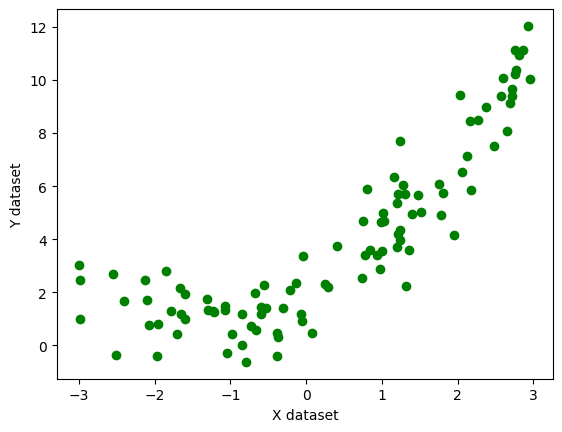

In [5]:
X = 6*np.random.rand(100,1)-3
y = 0.5*X**2 + 1.5*X + 2 + np.random.randn(100,1)
plt.scatter(X,y,color='g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')


In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
#let's implement a  simple linear regression
from sklearn.linear_model import LinearRegression
regression_1 = LinearRegression()

In [8]:
regression_1.fit(X_train,y_train)

LinearRegression()

In [9]:
from sklearn.metrics import r2_score
score = r2_score(y_test,regression_1.predict(X_test))
print(score)

0.7515987792524679


Text(0, 0.5, 'Y')

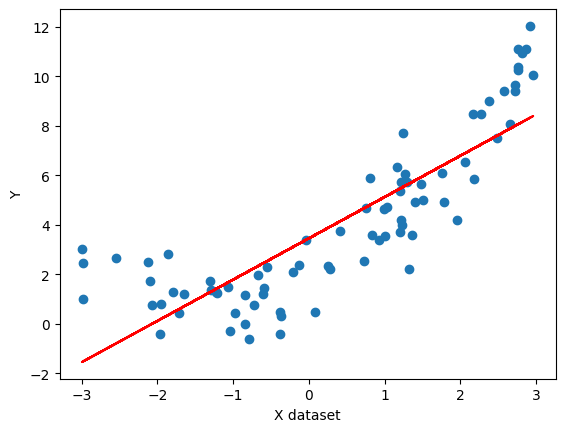

In [12]:
#Let's visualise this model
plt.plot(X_train,regression_1.predict(X_train),color='r')
plt.scatter(X_train,y_train)
plt.xlabel('X dataset')
plt.ylabel('Y')

In [13]:
#Let's apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures


In [14]:
poly = PolynomialFeatures(degree=2,include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [16]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly,y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test,y_pred)
print(score)

0.9113625778841309


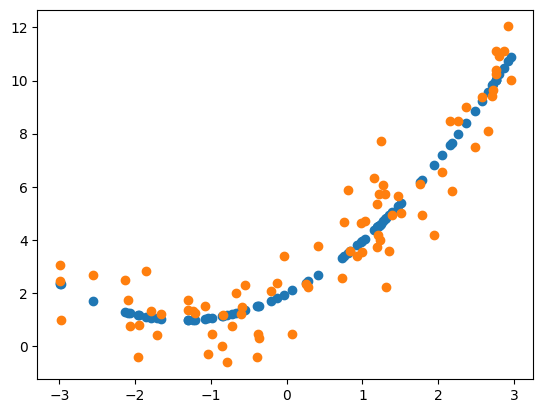

In [19]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train)

In [20]:
from sklearn.pipeline import Pipeline

In [25]:
def poly_regression(degree):
    X_new = np.linspace(-3,3,200).reshape(200,1)

    poly_features = PolynomialFeatures(degree=degree,include_bias = True)
    lin_reg = LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("line_reg",lin_reg)
    ])

    poly_regression.fit(X_train,y_train)
    y_pred_new = poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new,y_pred_new,'r',label='Degree'+str(degree),linewidth=3)
    # 'b.' means blue dots, 'g.' means green dots
    plt.plot(X_train, y_train, 'b.', label='Training data') 
    plt.plot(X_test, y_test, 'g.', label='Testing data')
    plt.legend(loc='best')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.axis([-4,4,0,10])
    plt.show()





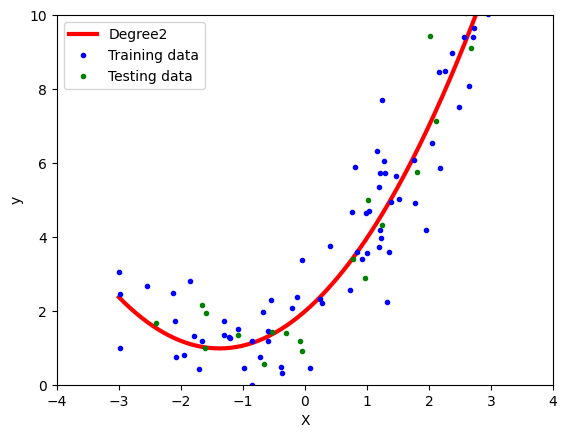

In [26]:
poly_regression(2)